# LeetCode #260: Single Number III

https://leetcode.com/problems/single-number-iii/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (Hash Map)** | $O(n)$ | $O(n)$ |
| **XOR Partition by Lowest Differing Bit** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (Hash Map)
Count occurrences with a hash map and return the two numbers with count 1. Correct, but uses $O(n)$ space for the map.

### Optimal: XOR Partition by Lowest Differing Bit ★
XOR all elements to get $x \oplus y$ (the two unique values). Find any bit where $x$ and $y$ differ — the lowest set bit of $x \oplus y$. Partition the array into two groups by that bit: each group contains exactly one unique number (all duplicates cancel within their group via XOR). XOR each group independently to extract $x$ and $y$.

**Why this is better than Brute Force:** Uses $O(1)$ space — no map — by exploiting that pairs self-cancel under XOR, leaving only the two unique values separated by a strategically chosen bit mask.

**Constraints:**
* `2 <= nums.length <= 3 * 10^4`
* `-2^31 <= nums[i] <= 2^31 - 1`
* Each element appears exactly twice except for two elements which each appear once

## Solutions

### C#

In [ ]:
public int[] SingleNumber(int[] nums) {
    // XOR all numbers; duplicates cancel, leaving xorAll = x ^ y
    int xorAll = 0;
    foreach (int n in nums) xorAll ^= n;

    // Isolate the lowest bit where x and y differ
    int diff = xorAll & (-xorAll);

    // Partition into two groups by that bit; duplicates cancel, x and y emerge
    int a = 0;
    foreach (int n in nums) {
        if ((n & diff) != 0) a ^= n;
    }
    return new int[] { a, xorAll ^ a };
}

### Python

In [ ]:
from functools import reduce
from operator import xor

def singleNumber(self, nums: list[int]) -> list[int]:
    # XOR all elements; paired numbers cancel, yielding x ^ y
    xor_all = reduce(xor, nums)
    # Find the lowest bit position that separates x from y
    diff = xor_all & (-xor_all)
    # XOR numbers that have this bit set; duplicates cancel, leaving one unique value
    a = reduce(xor, (n for n in nums if n & diff))
    return [a, xor_all ^ a]

### Go

In [ ]:
func singleNumber(nums []int) []int {
    // Combine all elements with XOR; pairs cancel, leaving x ^ y
    xorAll := 0
    for _, n := range nums {
        xorAll ^= n
    }
    // The lowest set bit of xorAll is where x and y diverge
    diff := xorAll & (-xorAll)
    a := 0
    for _, n := range nums {
        // Group numbers by the differing bit; duplicates self-cancel within each group
        if n&diff != 0 {
            a ^= n
        }
    }
    return []int{a, xorAll ^ a}
}

### Rust

In [ ]:
pub fn single_number(nums: Vec<i32>) -> Vec<i32> {
    // XOR all values; paired elements cancel, xor_all = x ^ y
    let xor_all = nums.iter().fold(0, |acc, &n| acc ^ n);
    // Lowest set bit marks the bit position where x and y differ
    let diff = xor_all & (-xor_all);
    // XOR only numbers belonging to one group; the other unique value comes from xor_all
    let a = nums.iter().filter(|&&n| n & diff != 0).fold(0, |acc, &n| acc ^ n);
    vec![a, xor_all ^ a]
}

## Example Scenarios

**1. Common Case**
**Input:** nums = [1, 2, 1, 3, 2, 5]
XOR all → 3⊕5 = 6 (110). Lowest set bit = 2 (010). Group with bit 2 set: {2,2,6?} — actually numbers with bit 1 set: 2,2,3 → group XOR = 2^2^3 = 3. Other unique = 6^3 = 5. Result = **[3, 5]**.

**2. Slightly Complex**
**Input:** nums = [-1, 0, -1, 0, -3, 7]
XOR all = −3⊕7 = -3 XOR 7. In two's complement, −3=...11101, 7=0111 → XOR=...11010 = −6. Lowest set bit isolates the two negatives/positives into separate groups. Result = **[-3, 7]**.

**3. Edge Case: Time Factor**
**Input:** 30,000 elements, two passes over the full array (once to XOR all, once to partition)
Both loops are $O(n)$. The largest input stresses throughput but not correctness. The bit-mask partition always correctly isolates the two uniques. $O(n)$ time.

**4. Edge Case: Space Factor**
**Input:** nums = [1, 2]
Minimum: two elements, both unique. XOR = 3, diff = 1. Group with bit 0: [1] → a=1. Result = **[1, 2]**. Constant $O(1)$ space with no auxiliary structure.

**5. Almost-Impossible but Plausible**
**Input:** nums = [-2147483648, 2147483647, -2147483648, -2147483647]
Two unique values at extreme 32-bit boundaries. XOR of all: 2147483647 ⊕ -2147483647. The lowest differing bit correctly partitions them. Two's complement arithmetic handles boundary values without overflow.

### Infographic

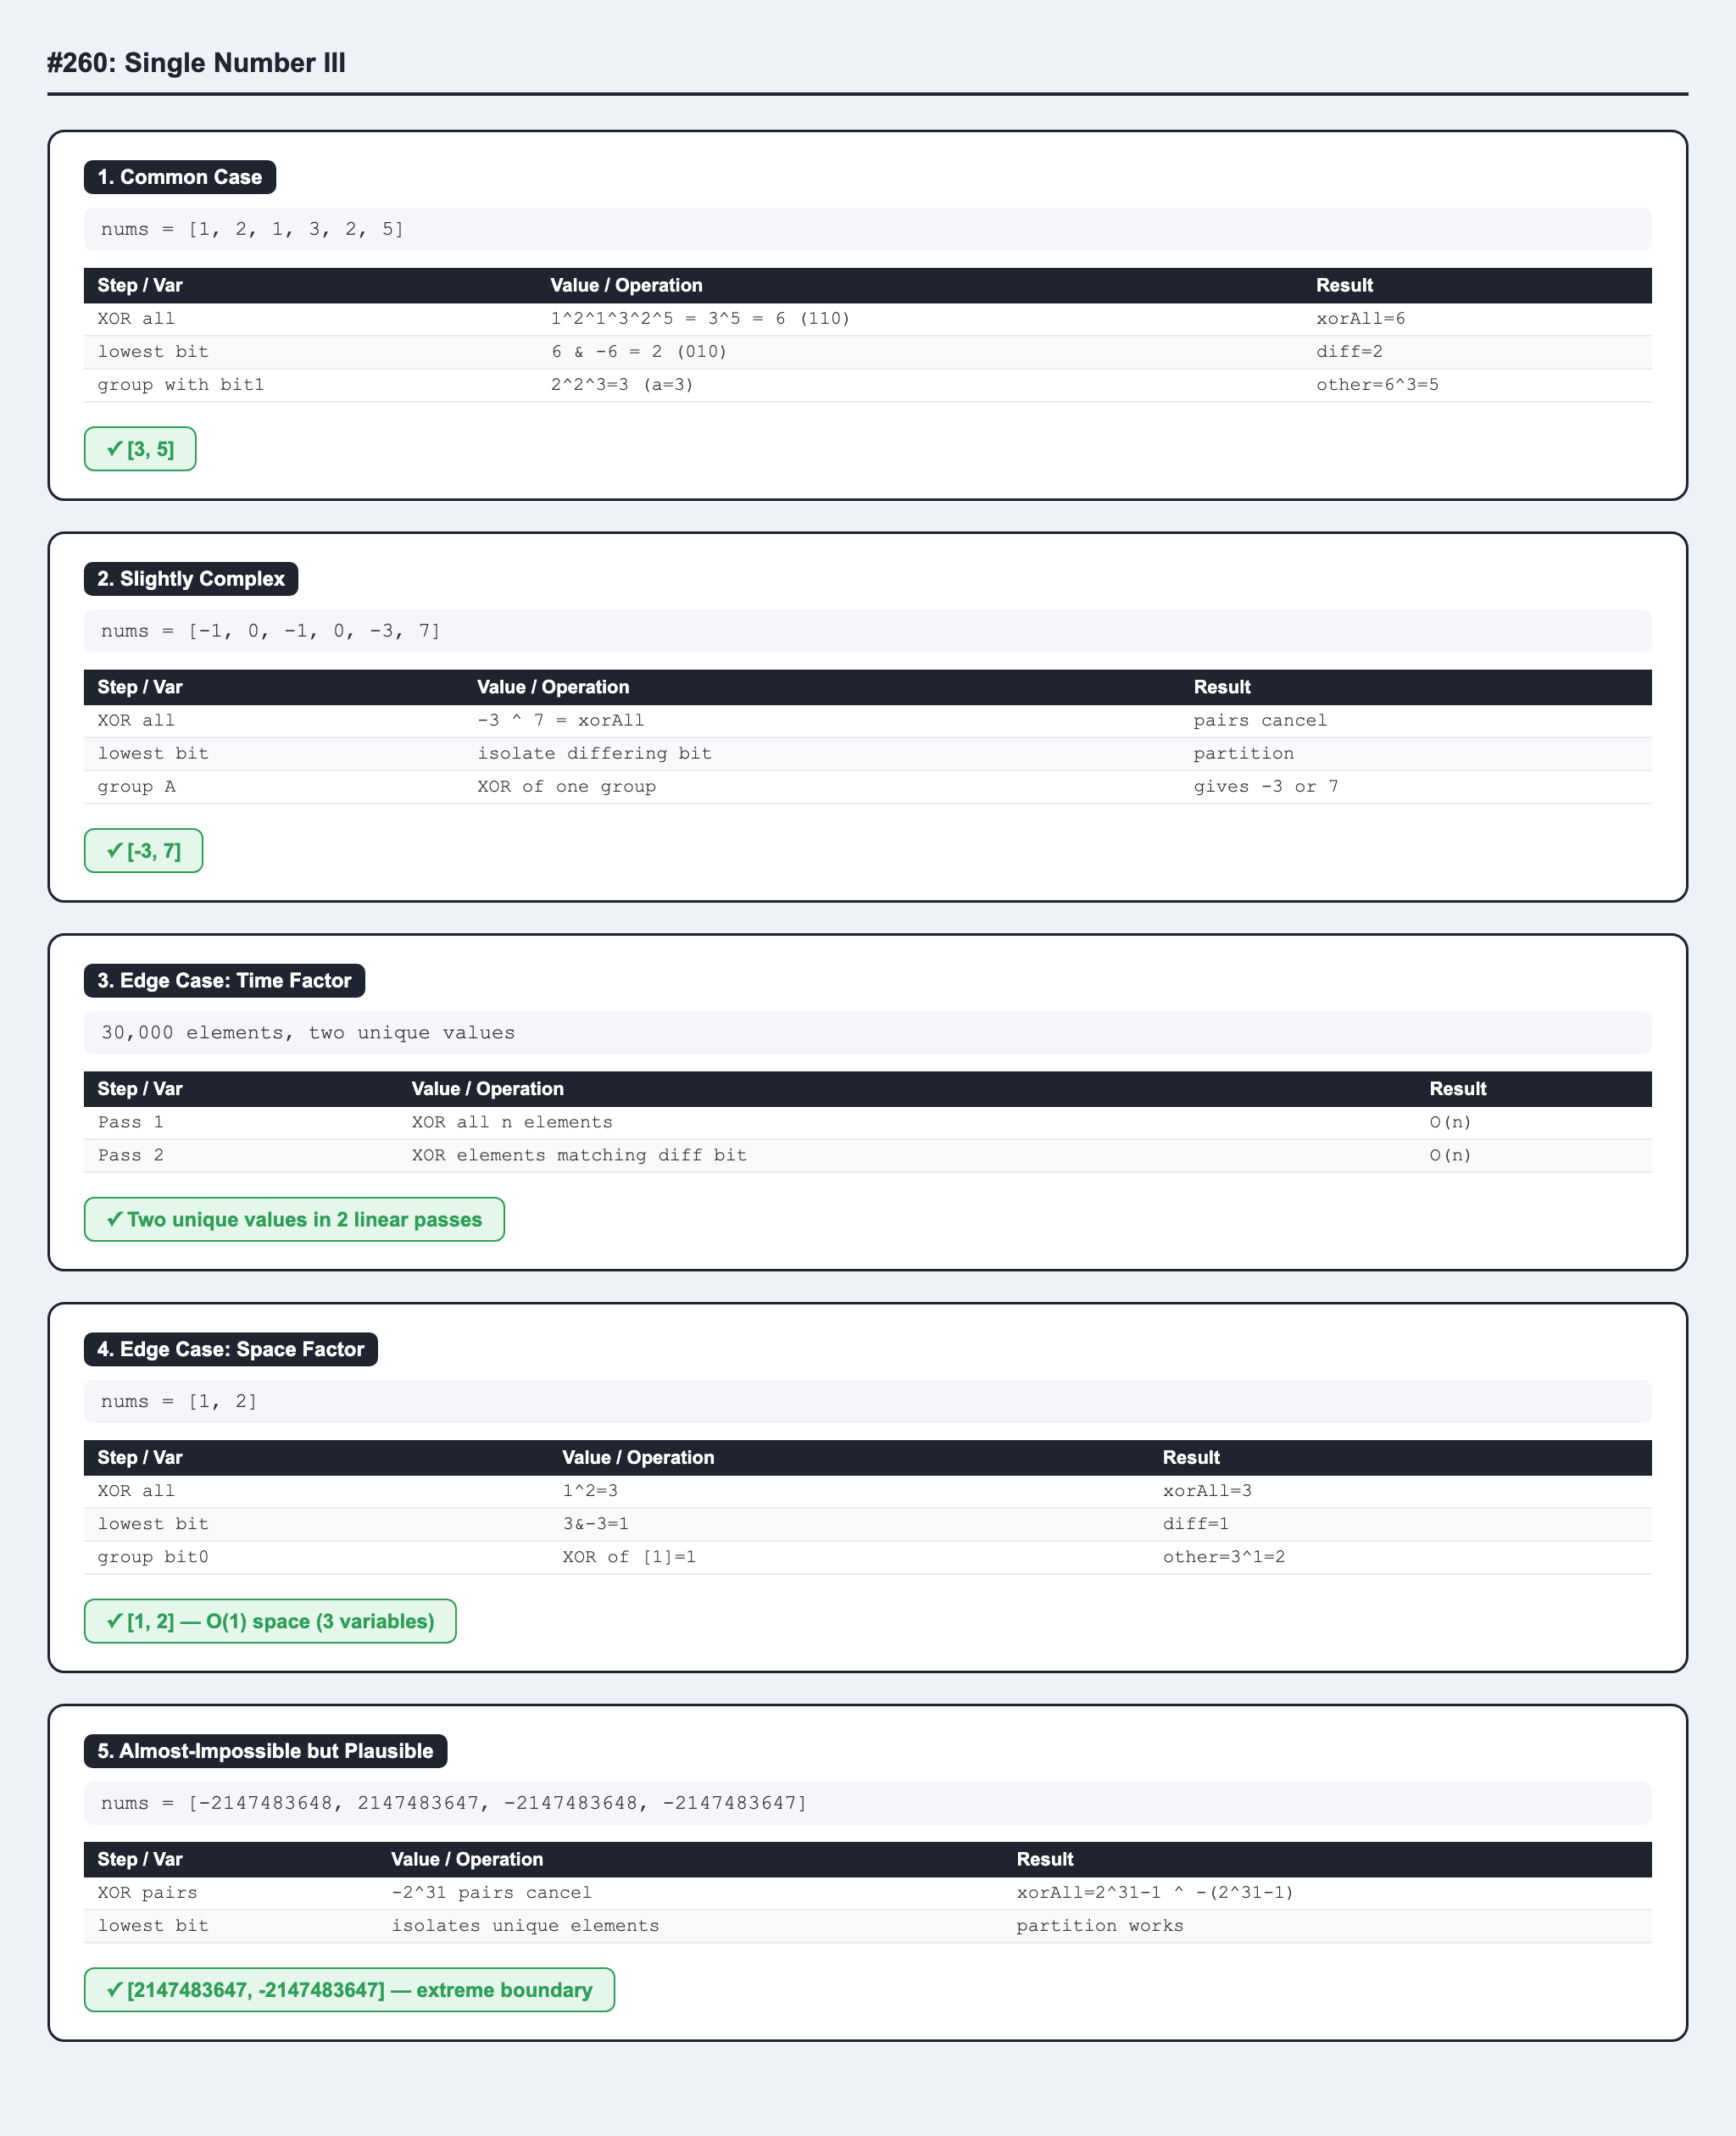